In [3]:
# pip install scikit-learn matplotlib seaborn
import numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay)
sns.set_theme(style='whitegrid', context='notebook')
np.random.seed(0)

In [4]:
iris = datasets.load_iris()
X, y = iris.data, iris.target
names = iris.target_names

# Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

2) Baselines: Linear vs RBF SVM
Linear margin: LinearSVC or SVC(kernel='linear')

Curved margin: SVC(kernel='rbf')

Always scale features for SVMs.

Linear SVM | Test accuracy: 0.974
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       1.00      0.92      0.96        13
   virginica       0.93      1.00      0.96        13

    accuracy                           0.97        38
   macro avg       0.98      0.97      0.97        38
weighted avg       0.98      0.97      0.97        38



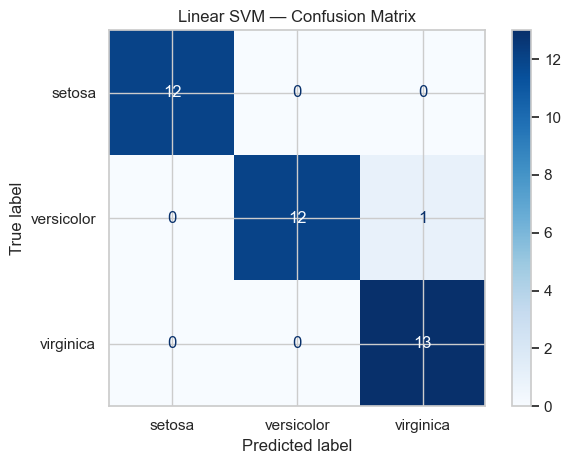

RBF SVM    | Test accuracy: 0.947
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.92      0.92      0.92        13
   virginica       0.92      0.92      0.92        13

    accuracy                           0.95        38
   macro avg       0.95      0.95      0.95        38
weighted avg       0.95      0.95      0.95        38



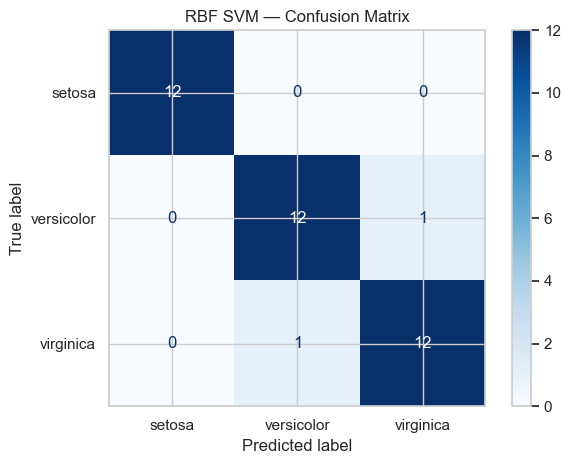

In [5]:
svc_lin = make_pipeline(StandardScaler(), SVC(kernel='linear', probability=True, random_state=0))
svc_rbf = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=0))

for name, clf in [("Linear SVM", svc_lin), ("RBF SVM", svc_rbf)]:
    clf.fit(X_train, y_train)
    y_pred  = clf.predict(X_test)
    acc     = accuracy_score(y_test, y_pred)
    print(f"{name:10s} | Test accuracy: {acc:.3f}")
    print(classification_report(y_test, y_pred, target_names=names))
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=names).plot(cmap='Blues')
    plt.title(name + " — Confusion Matrix"); plt.tight_layout(); plt.show()

Binary AUC demo (optional): If you want ROC‑AUC, restrict to two classes (e.g., setosa vs versicolor) or switch dataset to a binary one (e.g., breast cancer). Example:

Binary ROC-AUC (setosa vs versicolor): 1.0


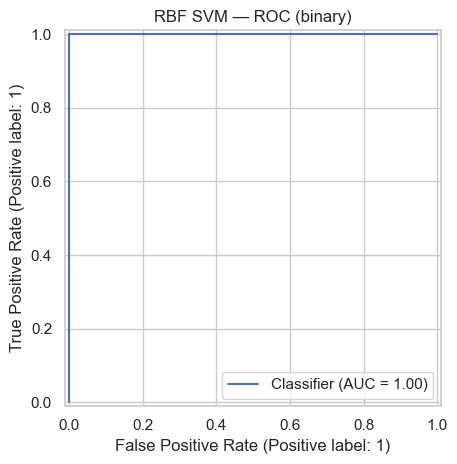

In [7]:
# Optional AUC on binary subset (setosa vs versicolor)
mask = y < 2
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(X[mask], y[mask], test_size=0.25, random_state=42, stratify=y[mask])
rbf_bin = make_pipeline(StandardScaler(), SVC(kernel='rbf', probability=True, random_state=0)).fit(Xb_tr, yb_tr)
proba = rbf_bin.predict_proba(Xb_te)[:,1]
# ✅ Fix: Use round(value, digits)
auc_score = roc_auc_score(yb_te, proba)
print("Binary ROC-AUC (setosa vs versicolor):", round(auc_score, 3))

RocCurveDisplay.from_predictions(yb_te, proba); plt.title("RBF SVM — ROC (binary)"); plt.tight_layout(); plt.show()

3) Hyperparameter tuning
Linear: tune C (margin softness).

RBF: tune C and γ (inverse length‑scale; higher → tighter, more complex boundary).

In [8]:
# Linear grid
grid_lin = GridSearchCV(
    make_pipeline(StandardScaler(), SVC(kernel='linear', probability=True, random_state=0)),
    param_grid={'svc__C': [0.01, 0.1, 1, 10, 100]},
    scoring='accuracy', cv=5, n_jobs=-1
).fit(X_train, y_train)
print("Best Linear params:", grid_lin.best_params_, "| CV acc:", round(grid_lin.best_score_, 3))

# RBF grid
grid_rbf = GridSearchCV(
    make_pipeline(StandardScaler(), SVC(kernel='rbf', probability=True, random_state=0)),
    param_grid={'svc__C': [0.1, 1, 10, 100],
                'svc__gamma': ['scale', 0.1, 0.5, 1, 2]},
    scoring='accuracy', cv=5, n_jobs=-1
).fit(X_train, y_train)
print("Best RBF params:", grid_rbf.best_params_, "| CV acc:", round(grid_rbf.best_score_, 3))

# Test performance of tuned models
for name, best in [("Linear SVM tuned", grid_lin.best_estimator_),
                   ("RBF SVM tuned",   grid_rbf.best_estimator_)]:
    y_pred = best.predict(X_test)
    print(f"{name:16s} | Test accuracy:", round(accuracy_score(y_test, y_pred), 3))

Best Linear params: {'svc__C': 0.1} | CV acc: 0.964
Best RBF params: {'svc__C': 1, 'svc__gamma': 0.1} | CV acc: 0.964
Linear SVM tuned | Test accuracy: 0.921
RBF SVM tuned    | Test accuracy: 0.921


4) Decision boundaries (2 features)
Plot using petal length & width (features 2,3).


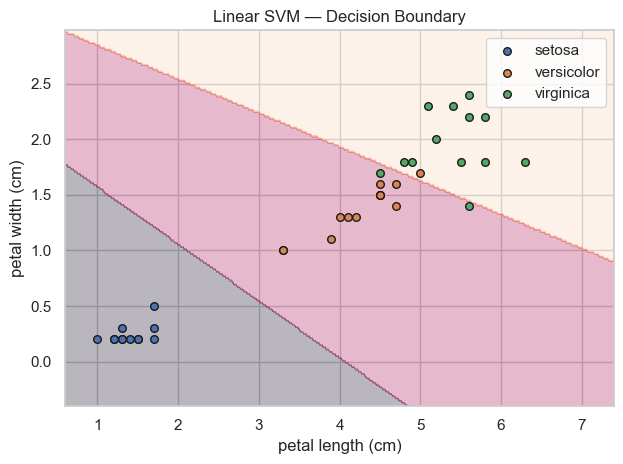

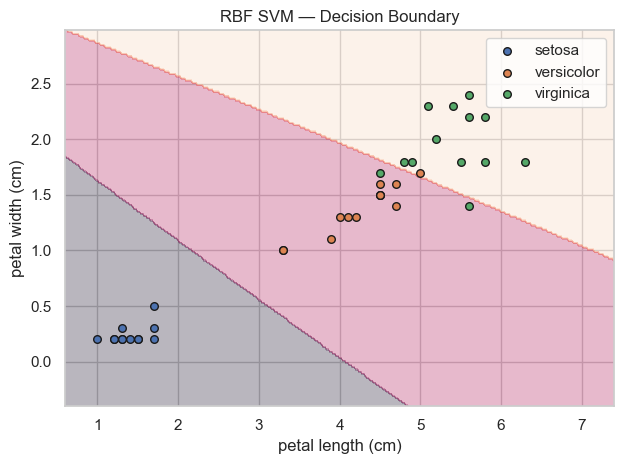

In [9]:
feat_idx = [2, 3]
X2 = X[:, feat_idx]
X2_tr, X2_te, y2_tr, y2_te = train_test_split(X2, y, test_size=0.25, random_state=42, stratify=y)

def plot_boundary(model, X, y, title, h=0.02):
    model.fit(X, y)
    x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5
    y_min, y_max = X[:,1].min()-0.5, X[:,1].max()+0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3)
    for i, lab in enumerate(names):
        pts = X2_te[y2_te==i]
        plt.scatter(pts[:,0], pts[:,1], label=lab, edgecolor='k', s=30)
    plt.title(title); plt.xlabel(iris.feature_names[feat_idx[0]]); plt.ylabel(iris.feature_names[feat_idx[1]])
    plt.legend(); plt.tight_layout(); plt.show()

plot_boundary(make_pipeline(StandardScaler(), SVC(kernel='linear', probability=True, random_state=0)),
              X2_tr, y2_tr, title='Linear SVM — Decision Boundary')

plot_boundary(make_pipeline(StandardScaler(), SVC(kernel='rbf', C=grid_rbf.best_params_.get('svc__C',1.0),
                                                  gamma=grid_rbf.best_params_.get('svc__gamma','scale'),
                                                  probability=True, random_state=0)),
              X2_tr, y2_tr, title='RBF SVM — Decision Boundary')

What to look for

Linear SVM draws (mostly) a straight boundary in 2D.

RBF SVM draws a curved boundary; higher γ → more wiggly (risk of overfit).

C controls margin softness: low C → wider margin, more bias; high C → tighter margin, more variance.

5) Robustness checks
Standardize features? (Yes, SVM needs it.)

Try class weights if classes are imbalanced: SVC(..., class_weight='balanced').

For speed on very high‑dimensional sparse text, prefer LinearSVC (no probabilities) or SGDClassifier(loss='hinge').